# Custom Imaging Model Definition in PyTorch

This notebook demonstrates how to create and integrate **custom imaging models** directly in PyTorch, without relying on predefined optics or modality classes.
It showcases the flexibility of the package for simulating complex imaging scenarios by defining your own forward models.

This is useful when:

* You want to prototype **new imaging physics** (e.g. other scattering models).
* You’re testing **simulated modalities** that don’t fit standard optics assumptions.
* You need a **lightweight differentiable forward operator** for research.

---

## Notebook Outline

1. **Define a Simple Imaging Model (Forward Operator)**

   Build a custom PyTorch `nn.Module` that maps a 3D volume to a 2D projection.

2. **Forward pass of our defined Imaging Model**

   Visualize the forward pass of our imaging model.

3. **Simulating the training data**

   Using the same code as in other notebooks, we simulate training data.

4. **Set up and run the Reconstruction Process**
   
   Following the same procedure as in other notebooks we set up and run the Reconstruction process.

5. **Visualizing the Reconstructed Volume and Rotation Parameters**

   Showing the result from the reconstruction process


In [1]:
# Uncomment if you run this notebook in Google Colab
#!pip install deeplay deeptrack plotly scipy opencv-python
#!git clone https://github.com/SkariZ/TomoDpDt.git
#import sys
#sys.path.append('/content/TomoDpDt')

In [2]:
# Uncomment if running this notebook locally
#import sys
#sys.path.append('..')

In [3]:
import sys
sys.path.append('..')

import tomodpdt

import os
import time
import numpy as np
import matplotlib.pyplot as plt

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import deeplay as dl
from torch.utils.data import DataLoader

In [5]:
DEV = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Using device:', DEV)

[suppressed training logs: 19 chars]


## 1. Defining a Simple Imaging Model

Let us define a simple imaging model implemented entirely in PyTorch. 

For demonstration purposes, the model performs a projection by summing along one axis, followed by a fixed Gaussian blur of the resulting image and a small addition of noise.

In [6]:
class SimpleImagingModel(nn.Module):
    """
    Custom differentiable imaging model:
    - Performs projection (sum along an axes)
    - Applies a learnable blur (optional)
    """

    def __init__(self, blur_kernel_size=5, sigma=1.0, apply_blur=True, dim=-1, microscopy_regime='model'):
        super().__init__()
        self.apply_blur = apply_blur
        self.blur_kernel_size = blur_kernel_size
        self.sigma = sigma
        self.dim = dim
        self.microscopy_regime = microscopy_regime

        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

        if apply_blur:
            coords = torch.arange(blur_kernel_size) - blur_kernel_size // 2
            x, y = torch.meshgrid(coords, coords, indexing="ij")
            kernel = torch.sin(0.3 * (x**2 + y**2))
            kernel = (kernel - kernel.min()) / (kernel.max() - kernel.min())  # normalize to [0,1]
            kernel /= kernel.sum()
            self.register_buffer("kernel", kernel[None, None, ...])

            self.kernel = self.kernel.to(self.device)

        self.fixed_noise = torch.randn(1, 1, 64, 64).to(self.device)

    def forward(self, volume):
        """
        Forward model: 3D volume -> 2D projection (optional blur)
        volume: tensor of shape (B, D, H, W)
        returns: tensor of shape (B, H, W)
        """
        # Simple projection along depth axis
        projection = volume.sum(dim=self.dim)
        
        # Optional convolution blur
        if self.apply_blur:
            
            # Make sure projection has shape (B, 1, H, W) for conv2d
            if projection.dim() == 3:
                projection = projection.unsqueeze(1)  # shape (B, 1, H, W)
            elif projection.dim() == 2:
                projection = projection.unsqueeze(0).unsqueeze(0)  # shape (1, 1, H, W)

            # Apply convolutional blur
            projection = F.conv2d(projection, self.kernel, padding=self.blur_kernel_size // 2)

            # Add slight noise for realism
            projection += 0.01 * self.fixed_noise[:, :, :projection.size(2), :projection.size(3)]  # Add slight noise for realism

            # Make sure to projection has shape (B, H, C) when returning
            if projection.dim() == 4 and projection.size(1) == 1:
                projection = projection.squeeze(1)  # shape (B, H, W)
            elif projection.dim() == 3 and projection.size(0) == 1:
                projection = projection.squeeze(0)  # shape (H, W)


        return projection

## 2. Forward pass of our defined Imaging Model

We start of by loading in a sample from our test_data folder and visualizing how it looks like...

In [7]:
data_folder = "../test_data"
volume  = np.load(os.path.join(data_folder, 'vol_potato1.npy')) - 1.33

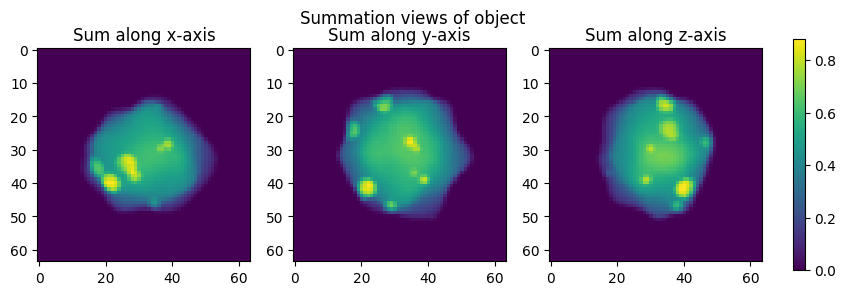

In [8]:
tomodpdt.plotting.plot_sum_object(volume)

Move the volume to pytorch tensor and to device...

In [9]:
volume = torch.tensor(volume, dtype=torch.float32).to(DEV)  

Define our imaging model and perform a forward pass of the volume...


In [10]:
imaging_model = SimpleImagingModel(blur_kernel_size=5, sigma=1.0, microscopy_regime='sumblur')
projections = imaging_model(volume)

In [11]:
print('Projections shape:', projections.shape)

Projections shape: torch.Size([1, 64, 64])


In [12]:
plt.figure(figsize=(4, 4))
plt.imshow(projections.squeeze().cpu().detach().numpy())
plt.title('Simulated Projection')

Text(0.5, 1.0, 'Simulated Projection')

## 3. Simulating the training data

In [13]:
test_object, q_gt, projections, imaging_model = tomodpdt.simulate.create_data(
    volume=volume.cpu().numpy(), # The volume we want to reconstruct
    image_modality=imaging_model, # Our custom imaging model
    rotation_case='smooth_varying_random', # We rotate the object around 1 main axis, but the other 2 axes are also non-zero an
    samples=150, # Number of projections
    duration=2 # Duration is the number of full revolutions
    )

[suppressed training logs: 20 chars]


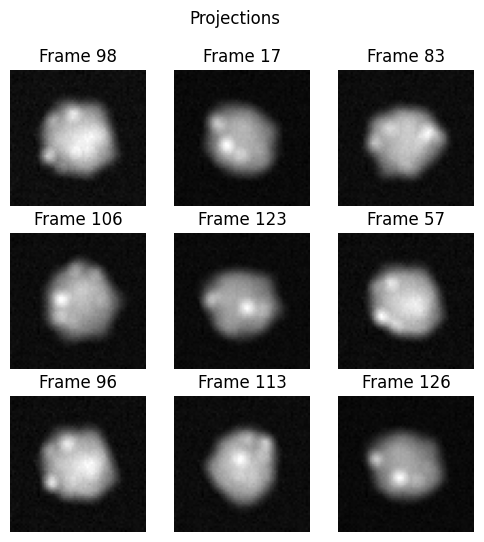

In [14]:
tomodpdt.plotting.plot_grid33_frames(projections, title="Projections", randomize=True)

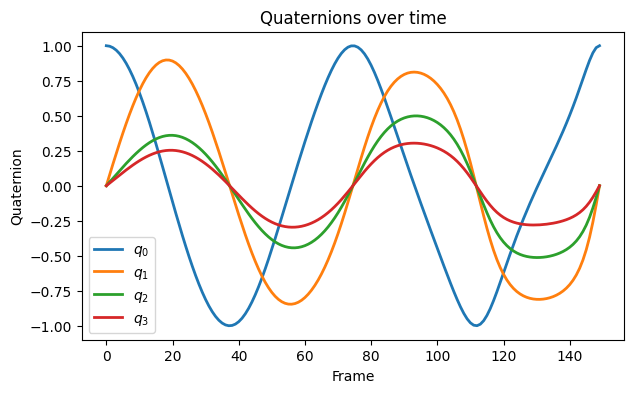

In [15]:
tomodpdt.plotting.plot_quaternions(q_gt)

## 4. Set up and run the Reconstruction Process

In [16]:
# Create the tomographic_model
tomographic_model = tomodpdt.Tomography(
    volume_size=volume.shape, # The size of the volume
    initial_volume='zeros', # 'refraction' since we are optimizing the refractive index
    rotation_optim_case='basis', # 'basis' or 'quaternion', 'basis' is smoother
    imaging_model=imaging_model, # The imaging model
    )

In [17]:
# Initialize the parameters
tomographic_model.initialize_parameters(projections, normalize=False, max_epochs=200)

[suppressed training logs: 1,784 chars]
---------------------------------------------------------------------
---------------------------------------------------------------------
169 K     Trainable params
0         Non-trainable params
169 K     Total params
0.677     Total estimated model params size (MB)
77        Modules in train mode
0         Modules in eval mode


[suppressed training logs: 618 chars]
c:\Users\Fredrik\miniconda3\envs\deeplaydev\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.


[suppressed training logs: 236 chars]


✅ Rotation initialization from latent space successful.


In [18]:
plotter = tomodpdt.plotting.TomoPlotter(tomographic_model)

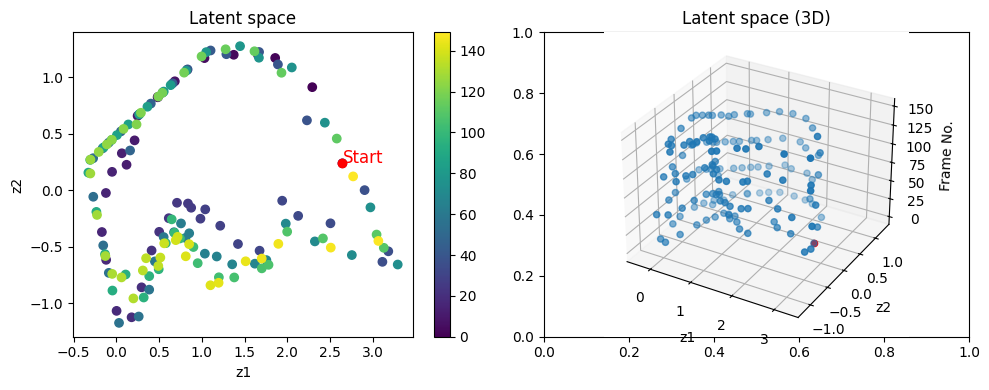

In [19]:
plotter.plot_latent_space()

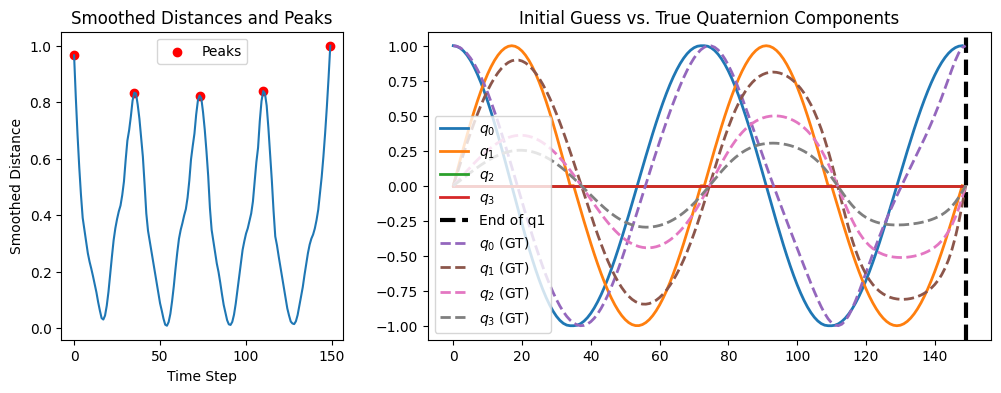

In [20]:
plotter.plot_smooth_dist_intial_guess(q_gt=q_gt)

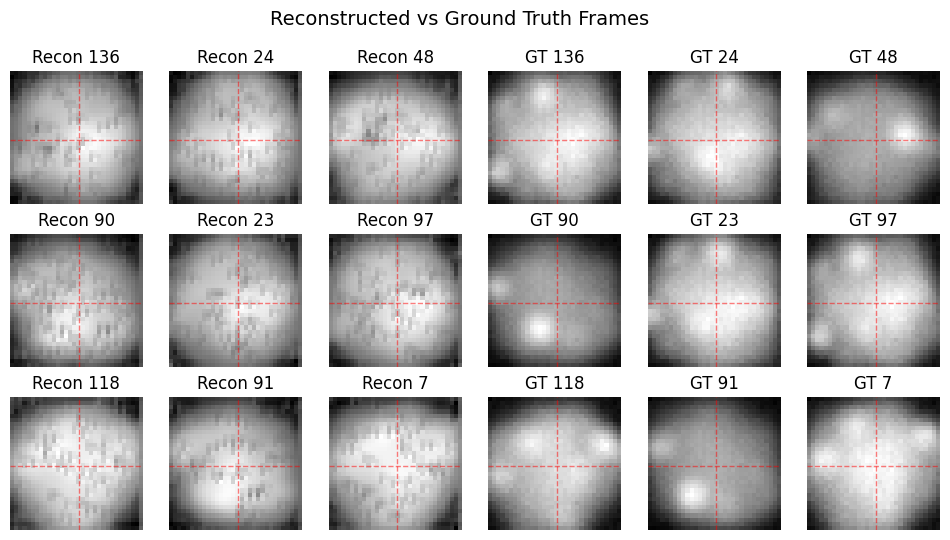

In [21]:
plotter.plot_reconstructed_vs_gt()

In [22]:
epochs_object_rot = 200 # Number of epochs for the object and rotation optimization
batch_size_object_rot = 16 # Batch size for the object and rotation optimization

and train the model for `epochs_object_rot` epochs...

In [23]:
# The gradients of the translation parameters are already False and remain so since we do not want to optimize them now
tomographic_model.toggle_gradients_translation(False)

# Move the model to device
tomographic_model.move_all_to_device(DEV)

In [24]:
N1 = len(tomographic_model.frames) # Number of frames
idx = torch.arange(N1) # List of indexes

[suppressed training logs: 926 chars]
-----------------------------------------------------------------
-----------------------------------------------------------------
262 K     Trainable params
169 K     Non-trainable params
431 K     Total params
1.728     Total estimated model params size (MB)
83        Modules in train mode
0         Modules in eval mode


[suppressed training logs: 295 chars]


[suppressed training logs: 236 chars]


[suppressed training logs: 43 chars]


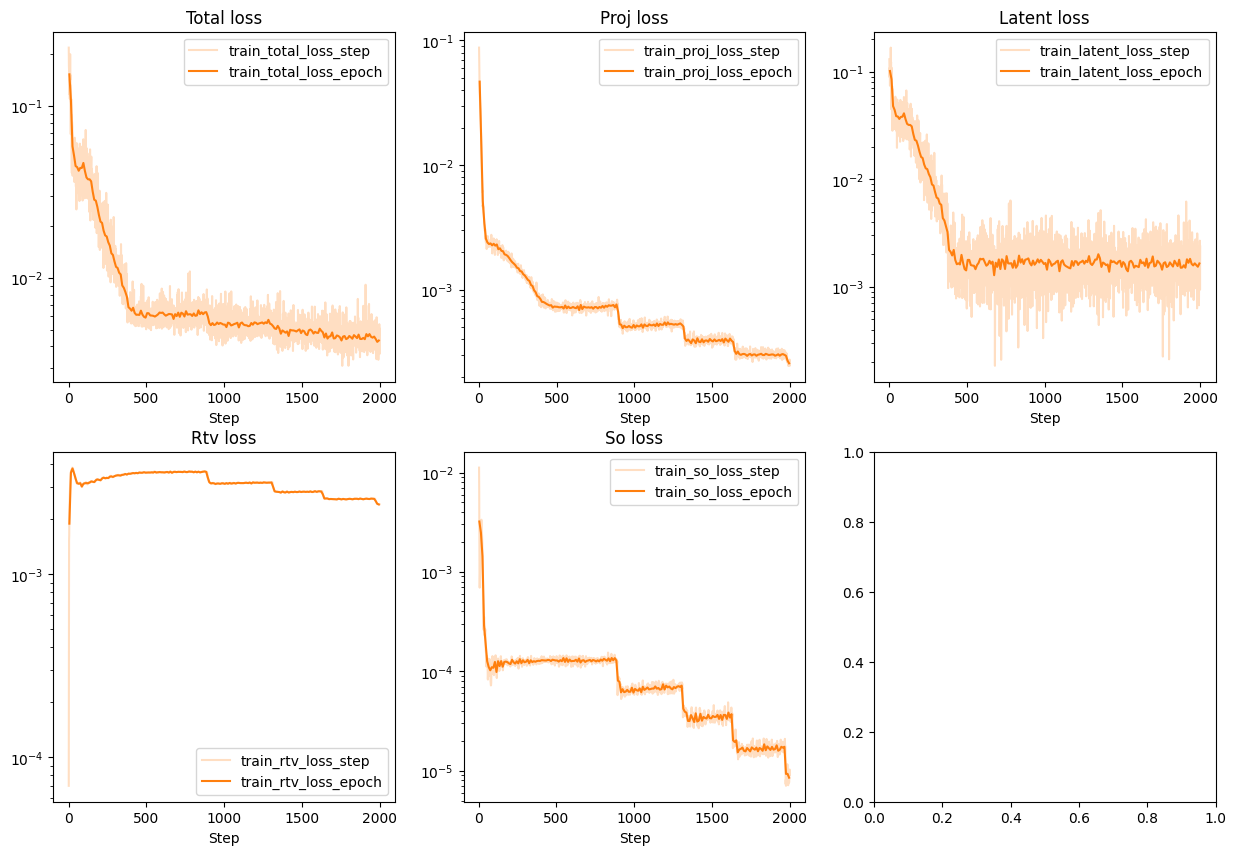

In [25]:
# Train the model
start_time = time.time()
trainer = dl.Trainer(max_epochs=epochs_object_rot, accelerator="auto", log_every_n_steps=None)
trainer.fit(tomographic_model, DataLoader(idx, batch_size=batch_size_object_rot , shuffle=True))
print("Training time: ", (time.time() - start_time) / 60, " minutes")

# Plot the training history
try:
    trainer.history.plot()
except:
    print("No history to plot...")

## 5. Visualizing the Reconstructed Volume and Rotation Parameters

After training, we can now visualize the **reconstructed 3D volume** and the corresponding **rotation parameters** to assess the quality of the reconstruction.

- The **reconstructed volume** is displayed as a 3D visualization (e.g., an isosurface, volume rendering, or orthogonal slices), providing an intuitive view of the recovered object structure.  
- The **rotation parameters** are shown as a 3D scatter plot in quaternion space (or as Euler angles), illustrating how the orientations evolve over time and how well they capture the rotational trajectory of the data.

Together, these visualizations help confirm that the reconstruction pipeline has correctly recovered both the **internal 3D structure** and the **motion geometry** of the system.


In [26]:
# Move it to the GPU if possible for faster plotting
tomographic_model.move_all_to_device(DEV)

# Visualize the final volume and rotations.
plotter = tomodpdt.plotting.TomoPlotter(tomographic_model)

By visualizing summation views of the 3D object along the x, y, and z axes, we can assess how well the optimized volume matches the ground truth.

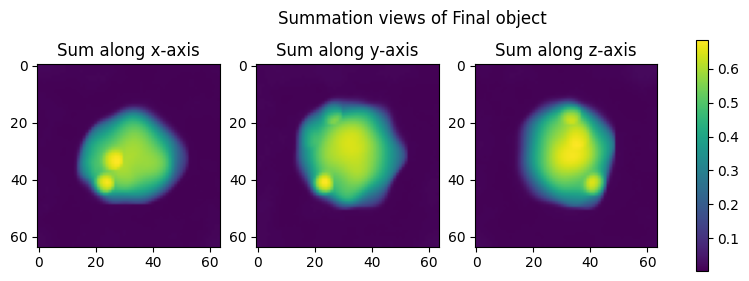

In [27]:
plotter.plot_sum_object(save_name="Final object")
plotter.plot_sum_object(obj=test_object.cpu(), save_name="Ground truth object")

Rather than showing simple summation views, we visualize the forward projections of the reconstructed volume and compare them to the ground truth 2D frames. A strong similarity between the two indicates that the 3D reconstruction and estimated rotations accurately reproduce the observed data.

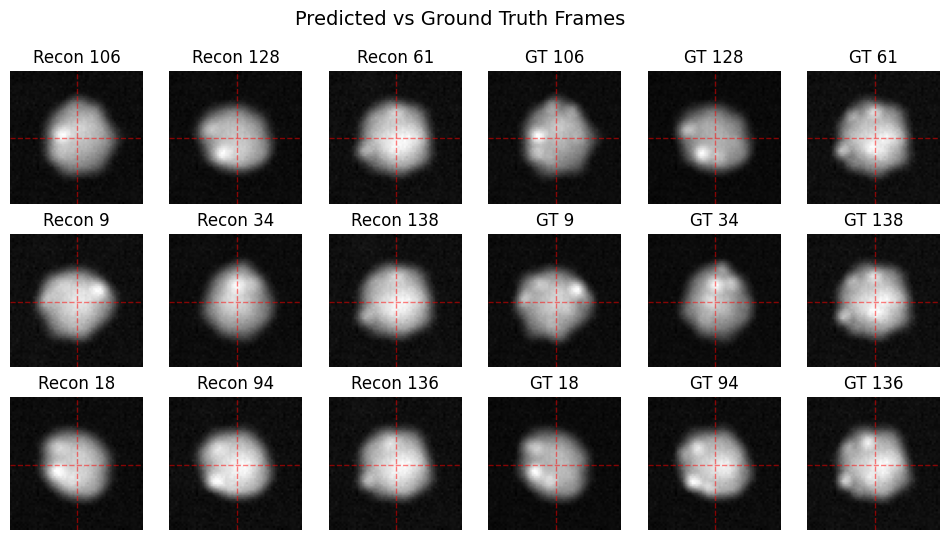

In [28]:
plotter.plot_reconstructed_vs_gt(column_headers=["Predicted", "Ground Truth"], forward=True, save_name="Reconstructed vs GT")

We can visualize the optimized quaternions and observe that they closely match the ground truth, demonstrating that the optimization successfully recovered the object’s rotational dynamics.

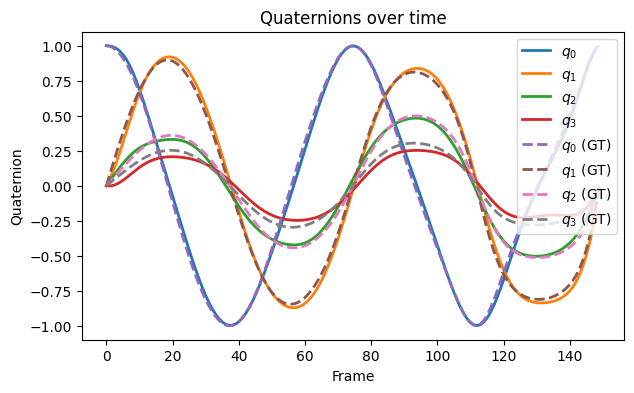

In [29]:
plotter.plot_quaternions(q_gt=q_gt)

The most effective way to visualize and compare the reconstructed volume to the ground truth is through interactive 3D plots using `plotly`.

In [30]:
# Uncomment belowto visualize the 3D volume
# tomodpdt.plotting.visualize_3d_volume(tomographic_model.volume.detach().cpu(), save_name="Final object 3D")
# tomodpdt.plotting.visualize_3d_volume(test_object.cpu(), save_name="Ground truth object 3D")